# SHAP Explainability – XGBoost Models (Multi-City)
This notebook computes and visualizes SHAP values for trained XGBoost accessibility models across cities.

## 1. Imports

In [1]:
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Patch

## 2. Plot Settings

In [2]:
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2
})

## 3. Configuration

In [3]:
MODEL_DIR = "../data/explainability/xgb_accessibility"

CITY_MAP = {
    "13_121_089_067_135": "Atlanta",
    "36_005_047_061_081": "New York",
    "08_031_005_059_035_001": "Denver",
    "25_025_009_017_021": "Boston"
}

## 4. Load models and compute SHAP values

In [4]:
def compute_city_shap(model_path, feature_path, X_path):
    model = joblib.load(model_path)
    feature_cols = joblib.load(feature_path)
    X = joblib.load(X_path)

    # align features
    X = X.reindex(columns=feature_cols, fill_value=0)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    return feature_cols, shap_values


all_results = []

for city_id, city_name in CITY_MAP.items():

    feature_cols, shap_values = compute_city_shap(
        f"{MODEL_DIR}/xgb_final_{city_id}.pkl",
        f"{MODEL_DIR}/features_{city_id}.pkl",
        f"{MODEL_DIR}/X_{city_id}.pkl"
    )

    df_city = pd.DataFrame({
        "feature": feature_cols,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
        "mean_shap": shap_values.mean(axis=0),
        "city": city_name
    })

    all_results.append(df_city)

shap_df = pd.concat(all_results, ignore_index=True)

## 5. Global feature importance (top features)

In [5]:
top_features = (
    shap_df
    .groupby("feature")["mean_abs_shap"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .index
)

top_features.tolist()

['distance_to_cbd_km',
 'land_area_km2',
 'intersection_density',
 'pct_car_commute',
 'street_density',
 'housing_density',
 'avg_household_size',
 'pct_black',
 'homeownership_rate',
 'pct_asian',
 'node_density',
 'transit_stop_density',
 'pct_hispanic_latino',
 'median_year_built',
 'pct_no_vehicle_households']

## 6. City comparison – mean SHAP (direction encoded)

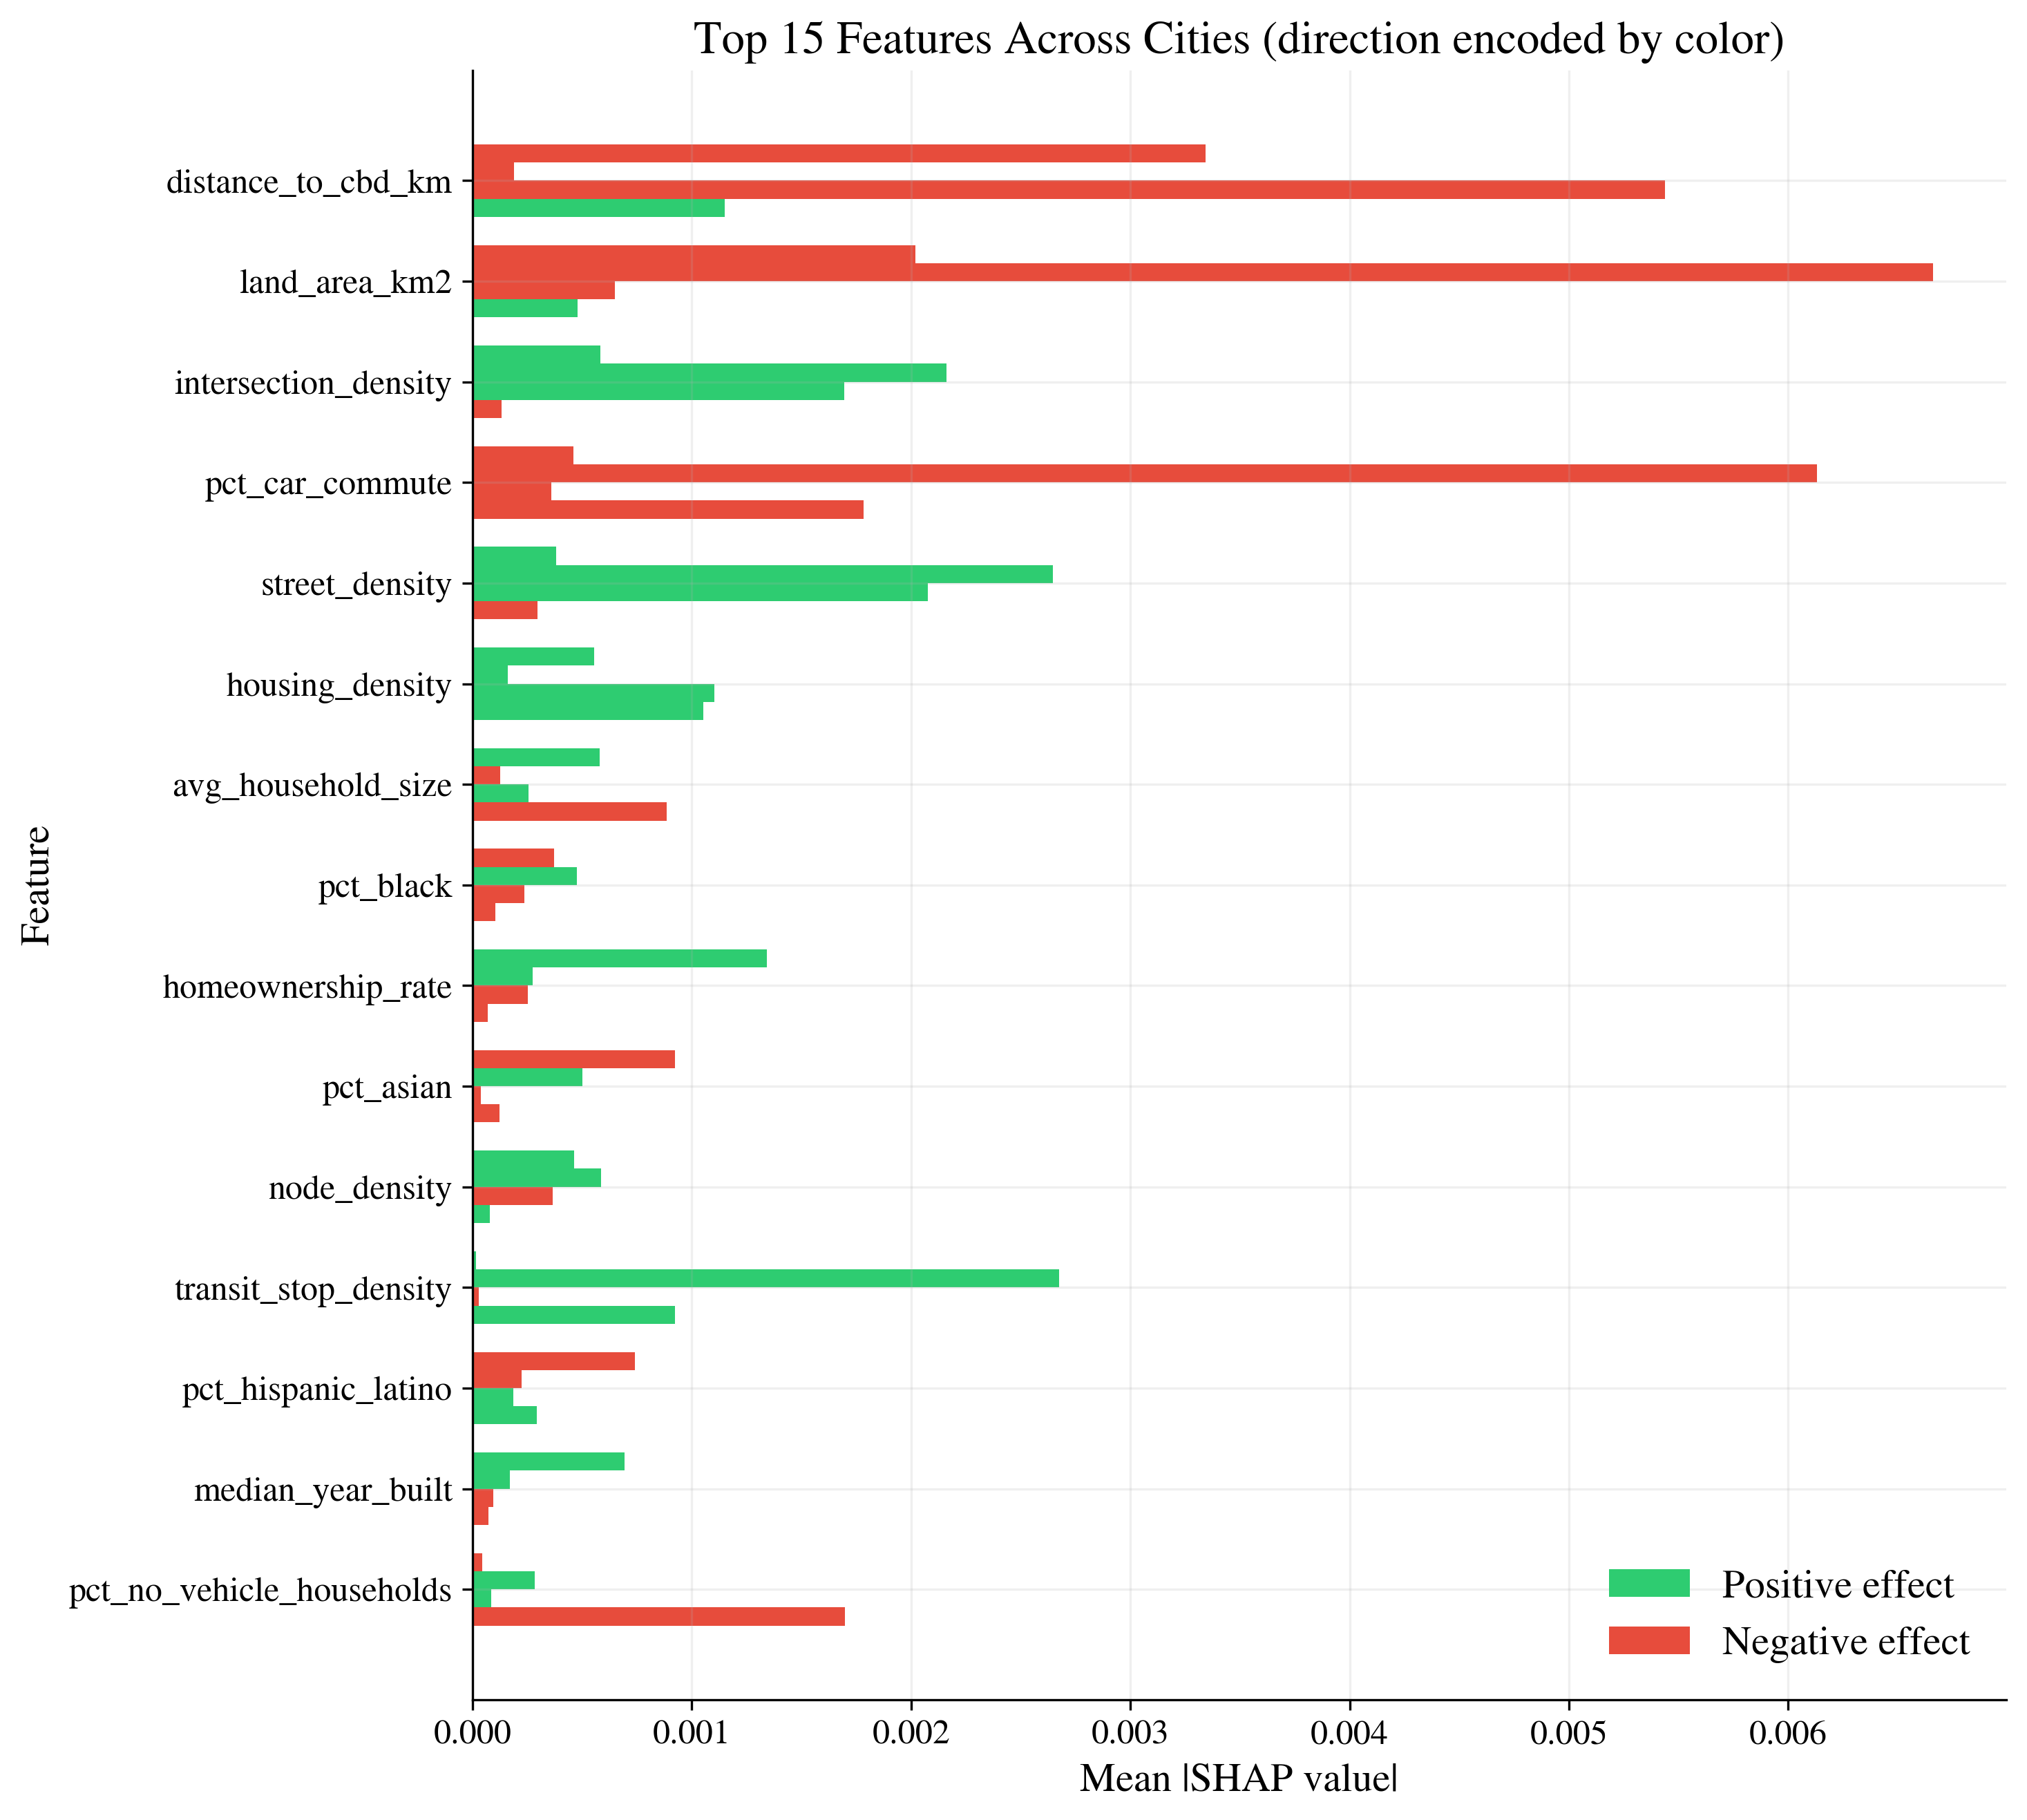

In [6]:
plot_df = shap_df[shap_df["feature"].isin(top_features)].copy()

pivot = plot_df.pivot_table(
    index="feature",
    columns="city",
    values="mean_shap",
    aggfunc="mean"
).reindex(top_features)

fig, ax = plt.subplots(figsize=(10, 9), dpi=300)

y = np.arange(len(top_features))
height = 0.18
cities = pivot.columns.tolist()

for i, city in enumerate(cities):
    vals = pivot[city].values
    abs_vals = np.abs(vals)

    colors = np.where(vals >= 0, "#2ecc71", "#e74c3c")

    ax.barh(
        y + (i - 1.5) * height,
        abs_vals,
        height=height,
        color=colors,
        edgecolor="none",
        label=city
    )

ax.set_yticks(y)
ax.set_yticklabels(top_features)

ax.set_xlabel("Mean |SHAP value|")
ax.set_ylabel("Feature")
ax.set_title("Top 15 Features Across Cities (direction encoded by color)")

ax.legend(
    handles=[
        Patch(facecolor="#2ecc71", label="Positive effect"),
        Patch(facecolor="#e74c3c", label="Negative effect")
    ],
    frameon=False,
    loc="lower right"
)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Global SHAP summary (aggregated across cities)

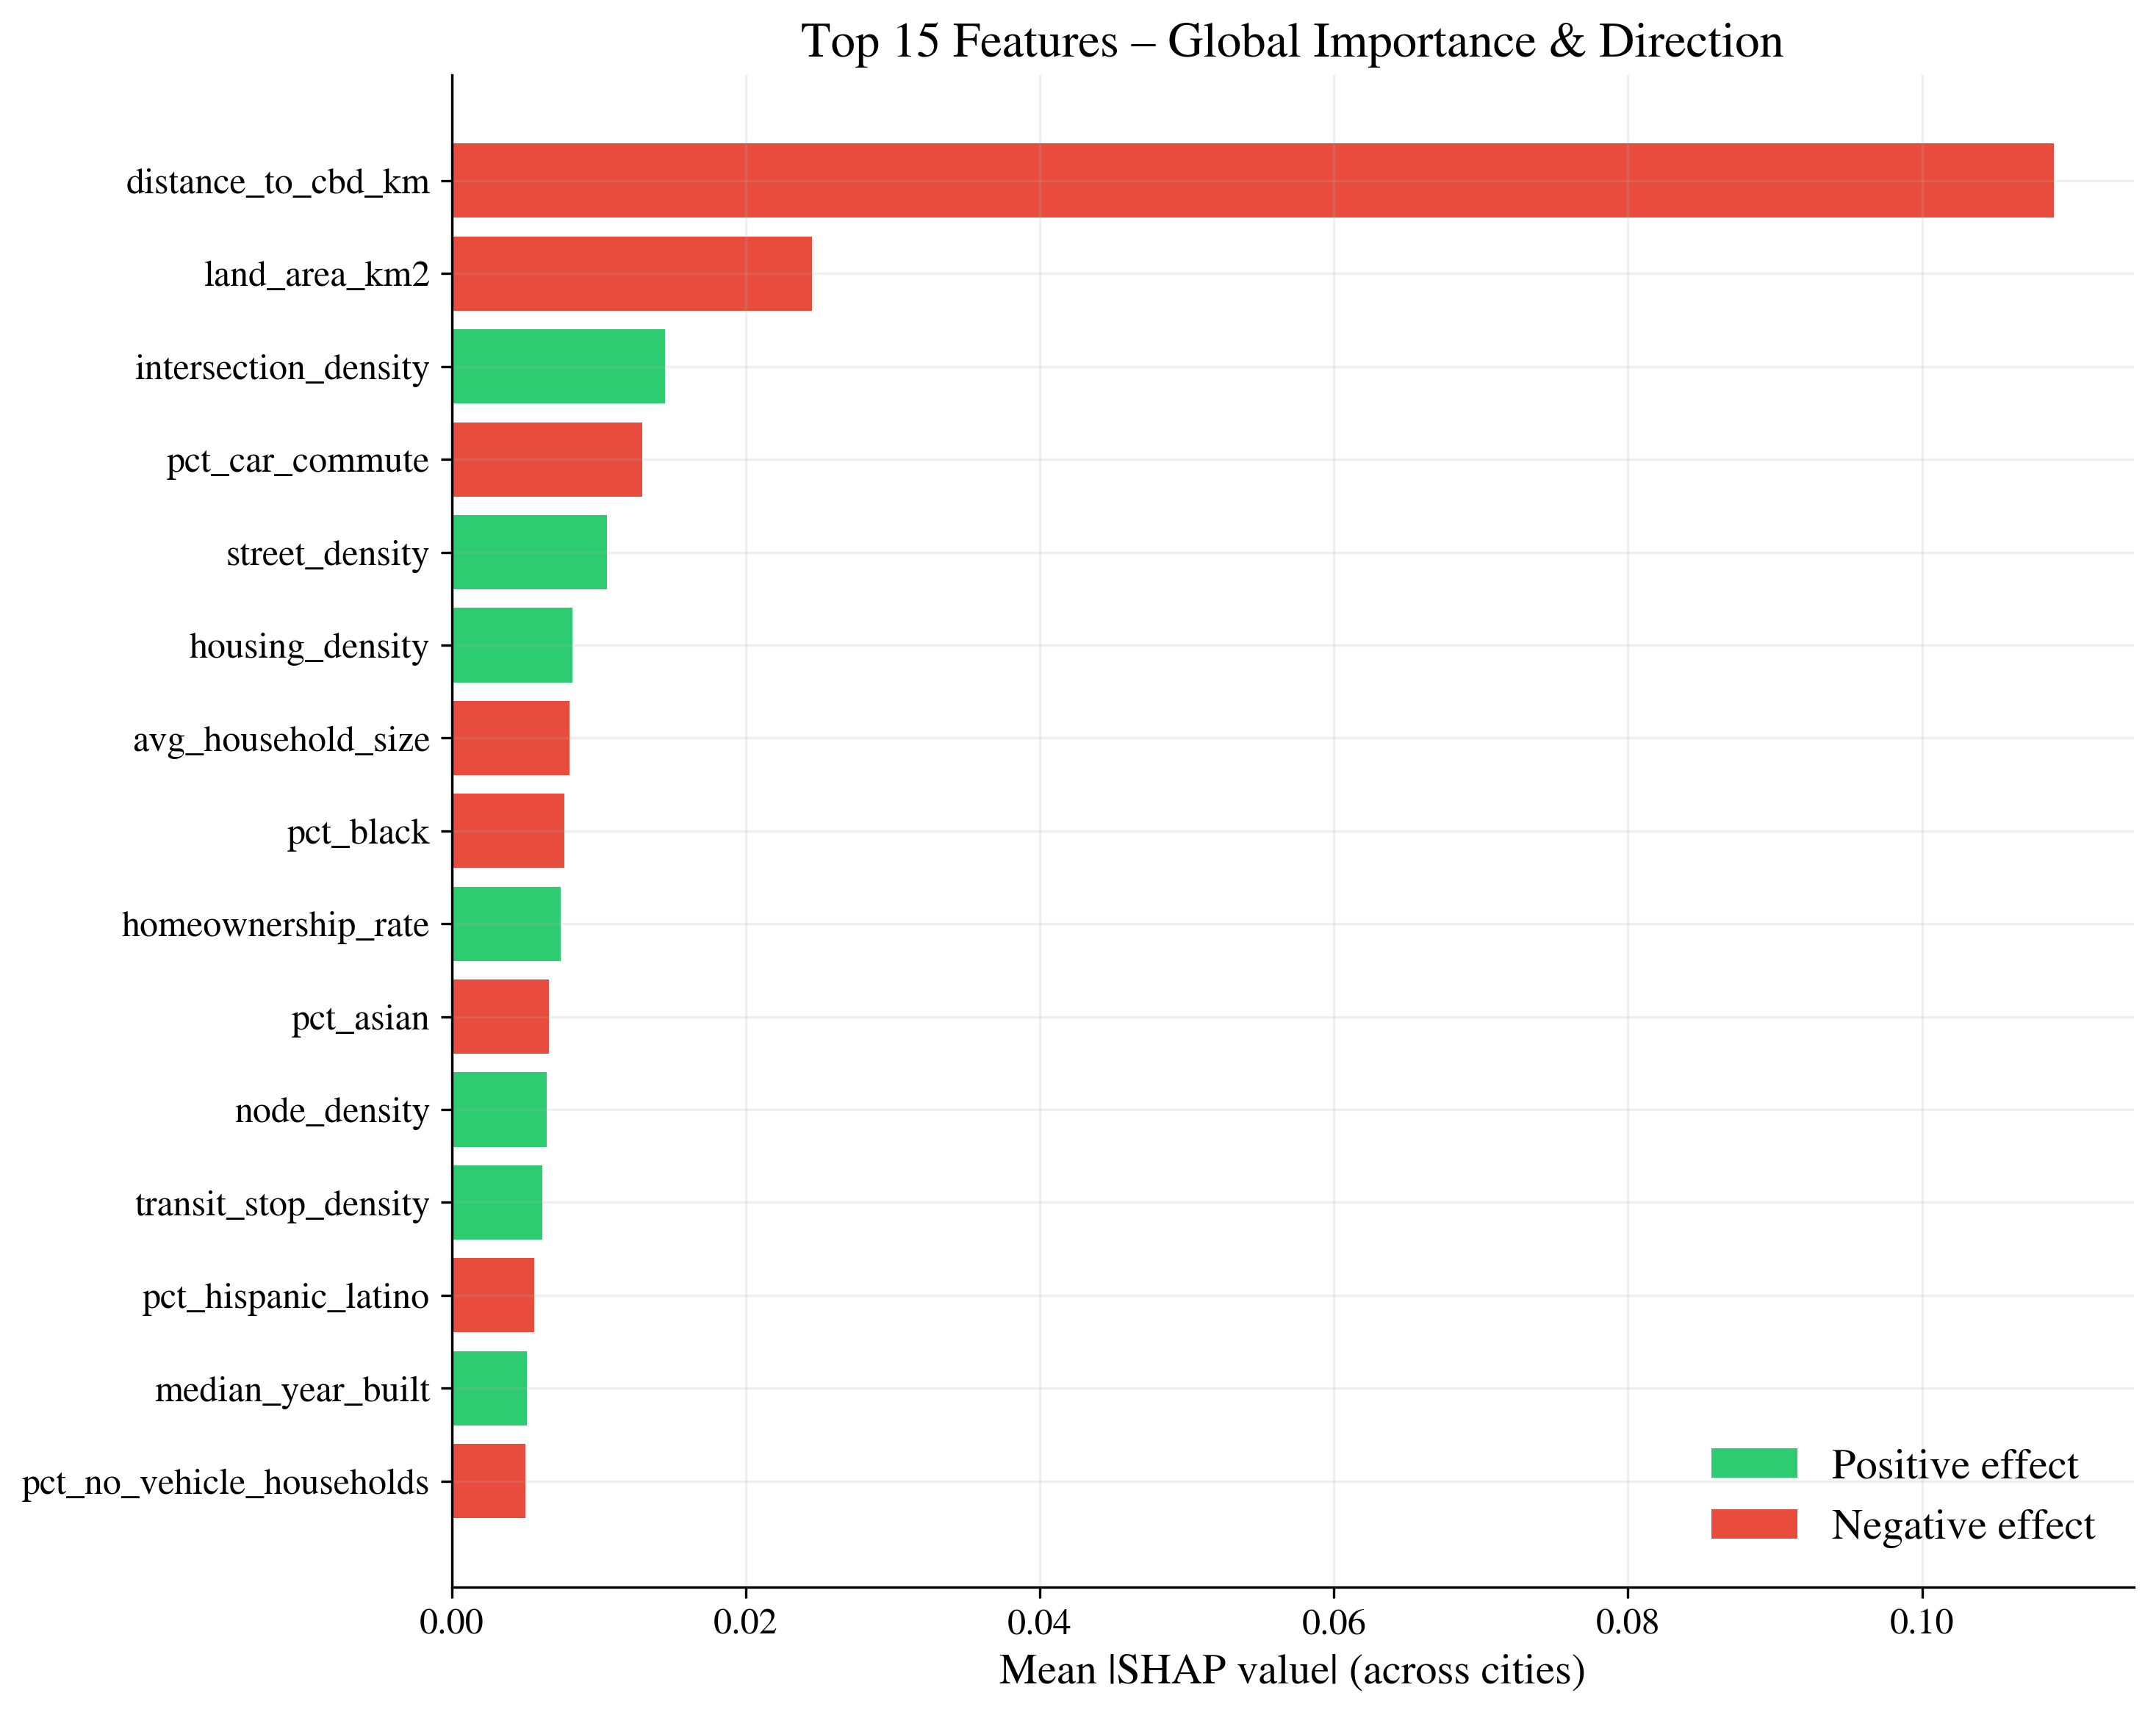

In [7]:
agg = (
    shap_df
    .groupby("feature")
    .agg(
        mean_shap=("mean_shap", "mean"),
        mean_abs_shap=("mean_abs_shap", "mean")
    )
    .loc[top_features]
)

colors = np.where(agg["mean_shap"] >= 0, "#2ecc71", "#e74c3c")

fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

ax.barh(
    agg.index,
    agg["mean_abs_shap"],
    color=colors
)

ax.set_xlabel("Mean |SHAP value| (across cities)")
ax.set_title("Top 15 Features – Global Importance & Direction")

ax.axvline(0, color="black", linewidth=1)

ax.invert_yaxis()

ax.legend(
    handles=[
        Patch(facecolor="#2ecc71", label="Positive effect"),
        Patch(facecolor="#e74c3c", label="Negative effect")
    ],
    frameon=False,
    loc="lower right"
)

plt.tight_layout()
plt.show()

## 8. SHAP beeswarm plots per city

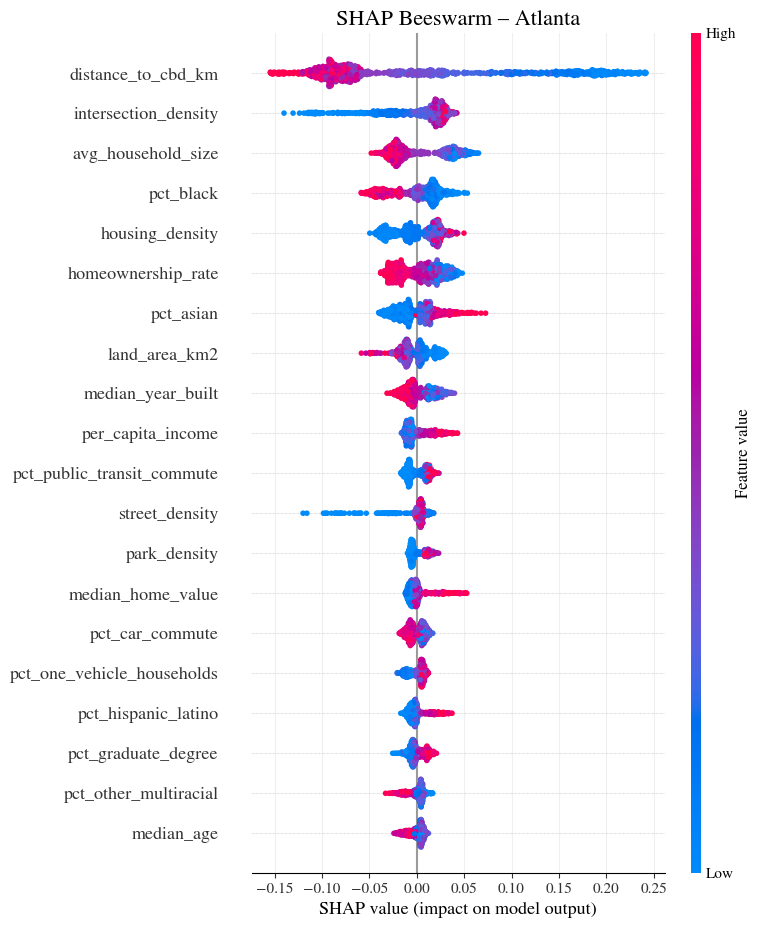

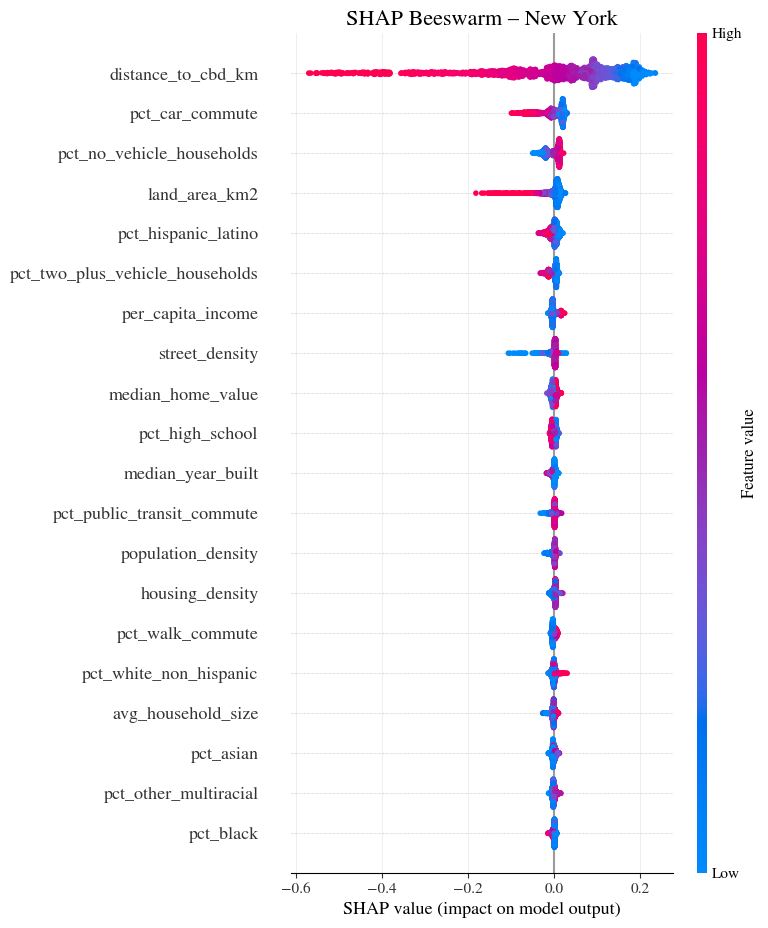

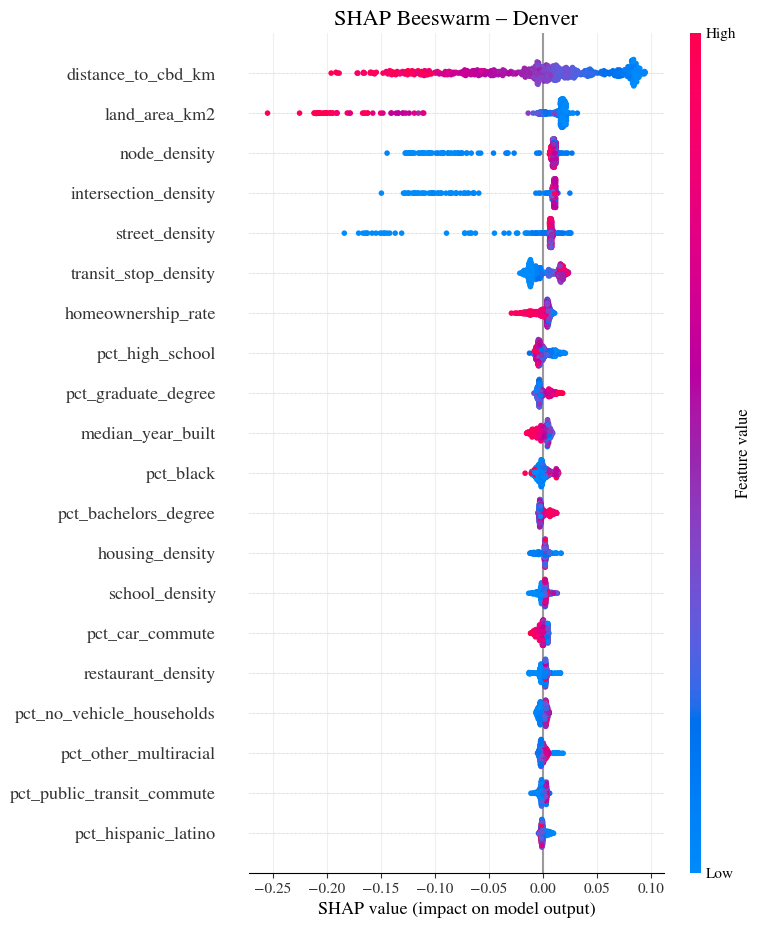

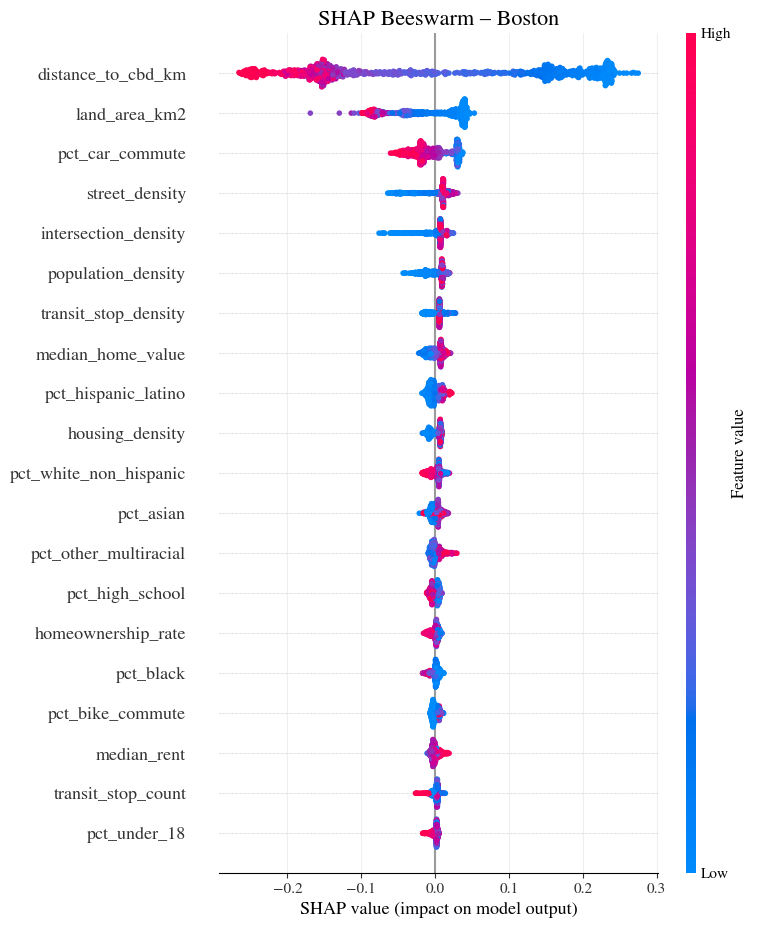

In [8]:
for city_id, city_name in CITY_MAP.items():

    model = joblib.load(f"{MODEL_DIR}/xgb_final_{city_id}.pkl")
    feature_cols = joblib.load(f"{MODEL_DIR}/features_{city_id}.pkl")
    X = joblib.load(f"{MODEL_DIR}/X_{city_id}.pkl")

    X = X.reindex(columns=feature_cols, fill_value=0)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    plt.figure()
    shap.summary_plot(
        shap_values,
        X,
        feature_names=feature_cols,
        show=False
    )

    plt.title(f"SHAP Beeswarm – {city_name}")
    plt.tight_layout()
    plt.show()